<a href="https://colab.research.google.com/github/Korobokkk/Kiselev_I_dsp-seminars/blob/kiselev_lab_3/KieselevIseminars/3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

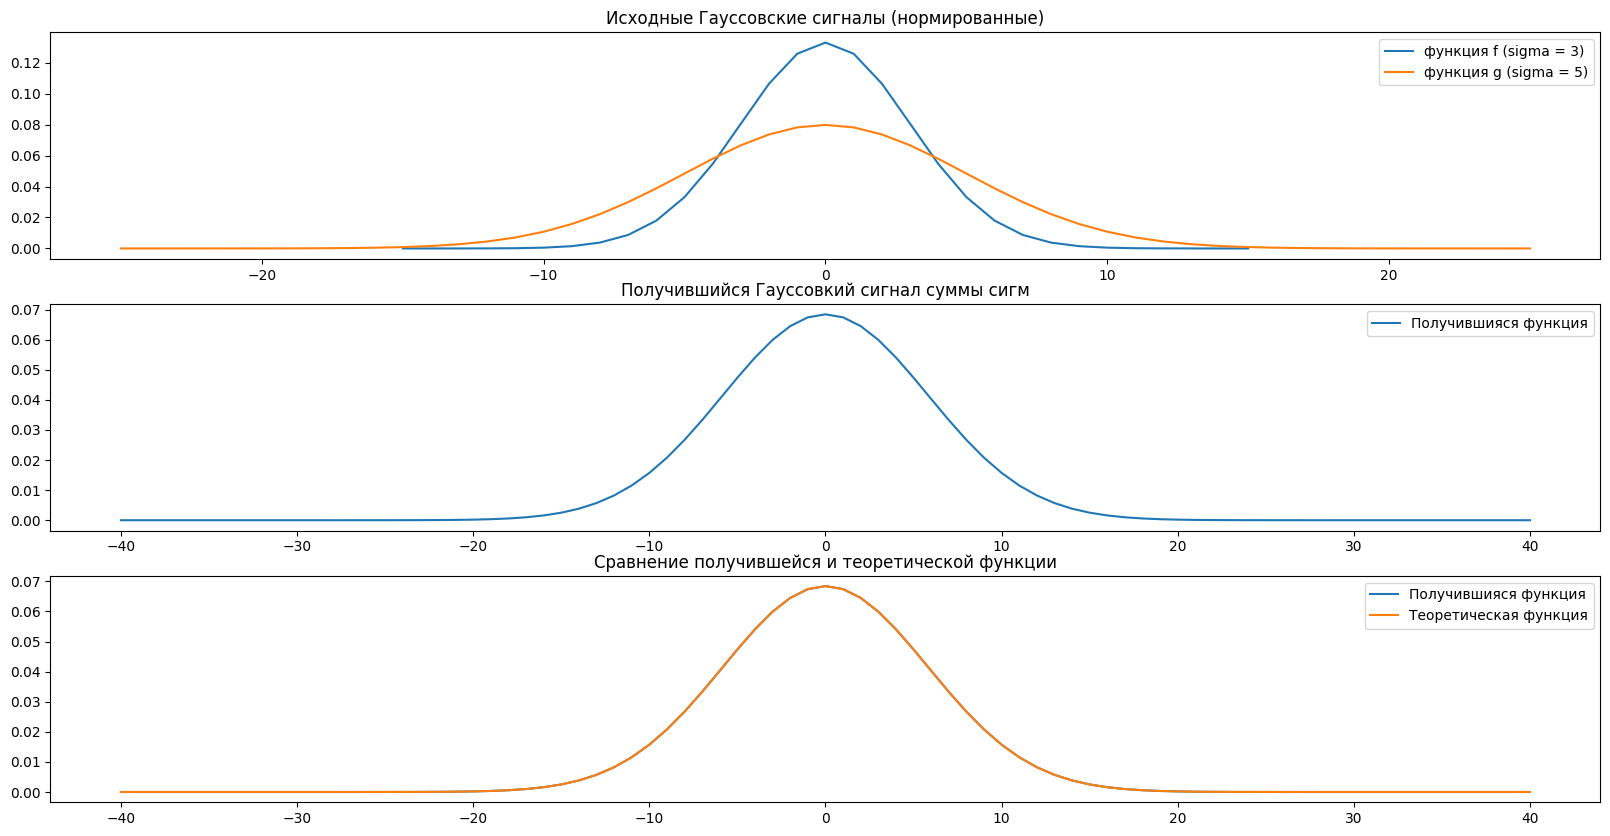

Средняя квадратическая ошибка = 2.4174613887108043e-16


In [104]:
sigma1 = 3
sigma2 = 5

M1 = 10 * sigma1 + 1
M2 = 10 * sigma2 + 1

f = signal.windows.gaussian(M1, sigma1)
g = signal.windows.gaussian(M2, sigma2)

f /= np.sum(f)
g /= np.sum(g)

f_res = np.convolve(f, g, mode='full')

disp_teor = sigma1 ** 2 + sigma2 ** 2
M3 = np.arange(M1 + M2 - 1) - (M1 + M2 - 1) // 2
f_teor = np.exp(-M3**2 / (2 * disp_teor))
f_teor /= np.sum(f_teor)
# print (f)
# print (g)
# print (M1)
# print (M2)
# print (len(f_res))
#print (len(f_teor))

t1 = np.arange(M1) - M1 // 2 # Адаптировал сдвиг по примеру Егашина Кирилла
t2 = np.arange(M2) - M2 // 2
t3 = np.arange(M1 + M2 - 1) - (M1 + M2 - 1) // 2

plt.figure(figsize=(20, 10))
plt.subplot(3, 1, 1)
plt.plot(t1, f, label = 'функция f (sigma = 3)')
plt.plot(t2, g, label = 'функция g (sigma = 5)')
plt.title('Иcходные Гауссовские сигналы (нормированные)')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t3, f_res, label = 'Получившияся функция')
plt.title('Получившийся Гауссовкий сигнал суммы сигм')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t3, f_res, label = 'Получившияся функция')
plt.plot(M3, f_teor, label = 'Теоретическая функция')
plt.title('Сравнение получившейся и теоретической функции')
plt.legend()

plt.show()


mse = np.mean((f_teor - f_res) ** 2)
print(f'Средняя квадратическая ошибка = {mse}')


**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?

{Введите ваш ответ здесь}

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

TypeError: 'tuple' object is not callable

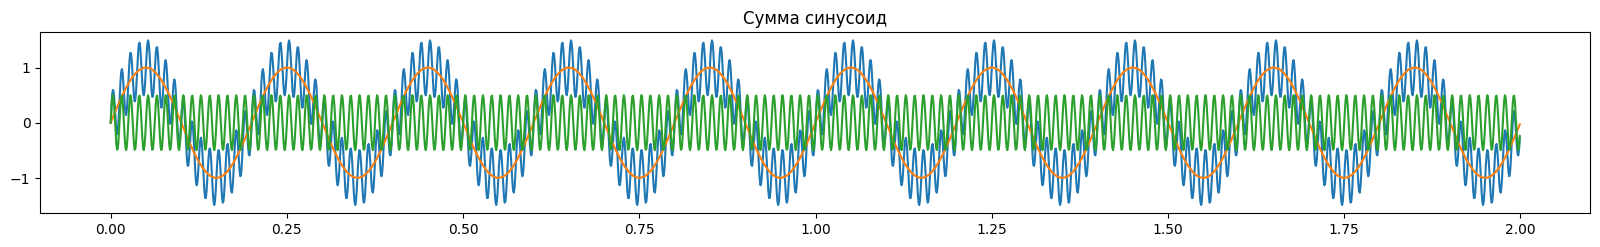

In [105]:
f_1 = 5
A_1 = 1
f_2 = 80
A_2 = 0.5

fs = 1000
time = np.arange(0, 2, 1/fs)

sin_1 = A_1 * np.sin(2 * np.pi * f_1 * time)
sin_2 = A_2 * np.sin(2 * np.pi * f_2 * time)
result_signal = sin_1 + sin_2

plt.figure(figsize = (20,8))

plt.subplot(3, 1, 1)
plt.title('Сумма синусоид')
plt.plot(time, result_signal, label = 'Получившаяся синусоида')
plt.plot(time, sin_1, label = 'Синусоида 5 Гц')
plt.plot(time, sin_2, label = 'Синусоида 80 Гц')
plt.xlim(0, 2)
plt.grid(True)
plt.legend()
plt.show()


L = 21
h_window = signal.windows.boxcar(L)/L

std = L/5
gauss_window = signal.windows.gaussian(L, std)
gauss_window/=np.sum(gauss_window)

plt.figure(figsize = (20,8))
plt.subplot(3, 1, 2)
plt.title('Генерю окна')
plt.plot(np.arange(L), h_window, label = 'Прямоугольное окно')
plt.plot(np.arange(L), gauss_window, label = 'Гауссово окно')
plt.legend()
plt.grid(True)
plt.xlim(0, 20)
plt.show()

#print(len(gauss_window))
#print(h)
conv = np.convolve(h_window, gauss_window, mode='same')

plt.figure(figsize = (20,8))
plt.subplot(3, 1, 3)
plt.title('Результат свертки 2-х окон')
plt.plot(np.arange(L), conv)
plt.xlim(0, 20)
plt.grid(True)
plt.show()


h_res_signal = np.convolve(result_signal, h_window, mode = 'same')
gauss_res_signal = np.convolve(result_signal, gauss_window, mode = 'same')
# print(len(h_res_signal))
# print(len(gauss_res_signal))

print('Графики:')
plt.subplot(3, 1, 1)
plt.title('Исходный сигнал')
plt.plot(time[:500], result_signal[:500])
plt.show()

plt.subplot(3, 1, 2)
plt.title('Свертки')
plt.plot(time[:500], h_res_signal[:500], label = 'Прямоугольное окно')
plt.plot(time[:500], gauss_res_signal[:500], label = 'Гауссовское окно')
plt.legend()
plt.grid(True)
plt.show()


def get_spectrum(signal, fs):
    N = len(signal)
    X = np.fft.fft(signal)
    freq = np.fft.fftfreq(N, d=1/fs)

    half = N // 2
    return freq[:half], 2 * np.abs(X[:half]) / N

freq_pos, X_mag_orig = get_spectrum(result_signal, fs)
freq_pos_rect, X_mag_rect = get_spectrum(h_res_signal, fs)
freq_pos_gauss, X_mag_gauss = get_spectrum(gauss_res_signal, fs)

idx_5 = np.argmin(np.abs(freq_pos - 5))
idx_80 = np.argmin(np.abs(freq_pos - 80))

idx_5_h = np.argmin(np.abs(freq_pos_rect - 5))
idx_80_h = np.argmin(np.abs(freq_pos_rect - 80))

idx_5_g = np.argmin(np.abs(freq_pos_gauss - 5))
idx_80_g = np.argmin(np.abs(freq_pos_gauss - 80))

print("Амплитуды:")
print("Исходный: 5 Гц ",  X_mag_orig[idx_5], " 80 Гц ", X_mag_orig[idx_80])
print("Прямоугольное окно 5 Гц", X_mag_rect[idx_5], " 80 Гц ", X_mag_rect[idx_80])
print("Гаусс: 5 Гц", X_mag_gauss[idx_5], " 80 Гц ", X_mag_gauss[idx_80])
print('')


L_arr = [11, 21, 41, 81]
for i in L_arr:
  h_window = signal.windows.boxcar(i)/ i

  std = i/5
  gauss_window = signal.windows.gaussian(i, std)
  gauss_window/=np.sum(gauss_window)

  h_res_signal = np.convolve(result_signal, h_window, mode = 'same')
  gauss_res_signal = np.convolve(result_signal, gauss_window, mode = 'same')

  freq_pos, X_mag_orig = get_spectrum(result_signal, fs)
  freq_pos_rect, X_mag_rect = get_spectrum(h_res_signal, fs)
  freq_pos_gauss, X_mag_gauss = get_spectrum(gauss_res_signal, fs)

  idx_5 = np.argmin(np.abs(freq_pos - 5))
  idx_80 = np.argmin(np.abs(freq_pos - 80))

  idx_5_h = np.argmin(np.abs(freq_pos_rect - 5))
  idx_80_h = np.argmin(np.abs(freq_pos_rect - 80))

  idx_5_g = np.argmin(np.abs(freq_pos_gauss - 5))
  idx_80_g = np.argmin(np.abs(freq_pos_gauss - 80))

  print(f"Амплитуды: При L = {i}")
  print("    Прямоугольное окно 5 Гц", X_mag_rect[idx_5], " 80 Гц ", X_mag_rect[idx_80])
  print("    Гаусс: 5 Гц", X_mag_gauss[idx_5], " 80 Гц ", X_mag_gauss[idx_80])


**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?
- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?

{Введите ваш ответ здесь}

## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

In [ ]:
np.random.seed(42)

fs = 1000
t = np.arange(0, 1, 1 / fs)

freq_arr = np.random.uniform(10, 100, 100)
A_arr = np.random.uniform(0.5, 1.5, 100)
phase_arr = np.random.uniform(0, 2 * np.pi, 100)

x = np.zeros_like(t)
for i in range(100):
    x += A_arr[i] * np.sin(2*np.pi*freq_arr[i]*t + phase_arr[i])
x/= np.max(np.abs(x))

plt.plot(t, x)
plt.ylim(0,1)
plt.xlim(0,1)
plt.grid(True)
plt.show()

delay = 100
noise_level =0.1
noise_arr = noise_level * np.random.randn(len(x))

y = np.zeros_like(t)
y[delay:] = x[:-delay]
y += noise_arr
y /= np.max(np.abs(y))

plt.plot(t, y)
plt.xlim(0, 1)
plt.ylim(0,1)
plt.grid(True)
plt.show()

**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?
- Почему при высоком уровне шума могут появляться ложные пики?

{Введите ваш ответ здесь}

## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

In [ ]:
# Ваш код здесь

**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

{Введите ваш ответ здесь}

## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [ ]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O full_audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav"
!wget -O fragment.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav"

In [ ]:
# Ваш код здесь

**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?
- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли с помощью корреляционного анализа определить его во всех случаях? Возникают ли ложные максимумы?
- Что будет, если фрагмент не содержится в полном сигнале? Как это отразится на корреляции?

{Введите ваш ответ здесь}